# Proximal Policy Optimization Algorithm

The fundamental quesion of this solution is: "How can we have maximum possible step size in policy parameters without going too far and getting to a worse policy than the original one before the update?". It is ensured by introducting clip loss function.
It follows the same idea as A2C of having policy network and value network, as weel as multiple workers. However it limits update to policy network. Idea behind this method is to base update on the ratio of new and old policy. Another difference is that it uses multiple networks updates per data sample.



Paper: https://arxiv.org/abs/1707.06347

Open AI blog post: https://openai.com/blog/openai-baselines-ppo/

In [1]:
import os
import pprint
import random
import warnings
import numpy as np

from gym import Env
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy


import gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.env_util import make_vec_env

model_path = os.path.join('Training', 'Saved Models', 'best_model_PPO')

warnings.filterwarnings("ignore")

Prepare the enviroment

In [2]:
# SIM PARAMETERS
SLA = 50
VM_TYPE1 = 7
VM_TYPE2 = 3
VM_TYPE3 = 1
PENALTY = 10000
STEPS = 250
ALPHA = 0.5
BETA = 0.5
SCENARIO = "Environment/Scenarios/train_PPO.txt"

env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          penalty = PENALTY,
          steps = STEPS,
          scenario = SCENARIO,
          alpha = ALPHA,
          beta = BETA)

env = DummyVecEnv([lambda: env])
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

In [3]:
copy_scenario('train', 'PPO', 200)
copy_scenario('test_scenario_1', 'PPO')
copy_scenario('test_scenario_2', 'PPO')
copy_scenario('test_scenario_3', 'PPO')
copy_scenario('test_scenario_4', 'PPO')
copy_scenario('test_scenario_5', 'PPO')

Train the model

In [4]:
model = PPO('MlpPolicy', env, verbose = 1, learning_rate=1e-3, gamma=0.99)
model.learn(total_timesteps=1000, reset_num_timesteps = False)

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 0    |
|    iterations      | 1    |
|    time_elapsed    | 3437 |
|    total_timesteps | 2048 |
-----------------------------


In [5]:
model.save(model_path)

In [6]:
del model

In [7]:
model = PPO.load(model_path, env=env)

Evaluate the policy

In [8]:
evaluate_policy(model, env, n_eval_episodes=10, render=True)

(9.67749908566475, 1.6624654762958866)

Test the model

In [9]:
STEPS = 50

info {'Quality of Service': 64.14397550654621, 'Current cost': 765, 'Request': 30.0, 'Timer': 0.4676978588104248, 'VM type I': 13, 'VM type II': 8, 'VM type III': 3}


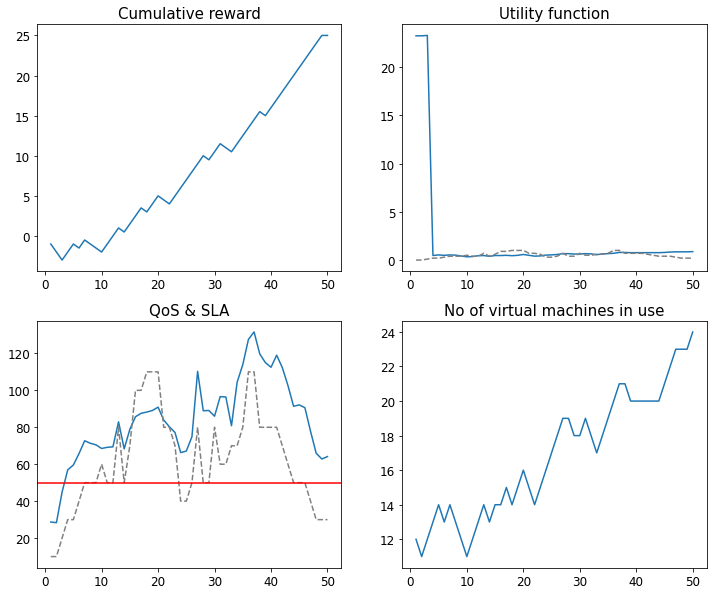

Cumulative reward at the end of the test:  25.0
Avg cost minus penalty per step:  1.97
Avg quality of service:  83.57
Avg no of virtual machines:  16.86


In [19]:
SCENARIO = 'Environment/Scenarios/test_scenario_1_PPO.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)

info {'Quality of Service': 21.755743528083542, 'Current cost': 60, 'Request': 170.0, 'Timer': 7.81402850151062, 'VM type I': 3, 'VM type II': 0, 'VM type III': 0}


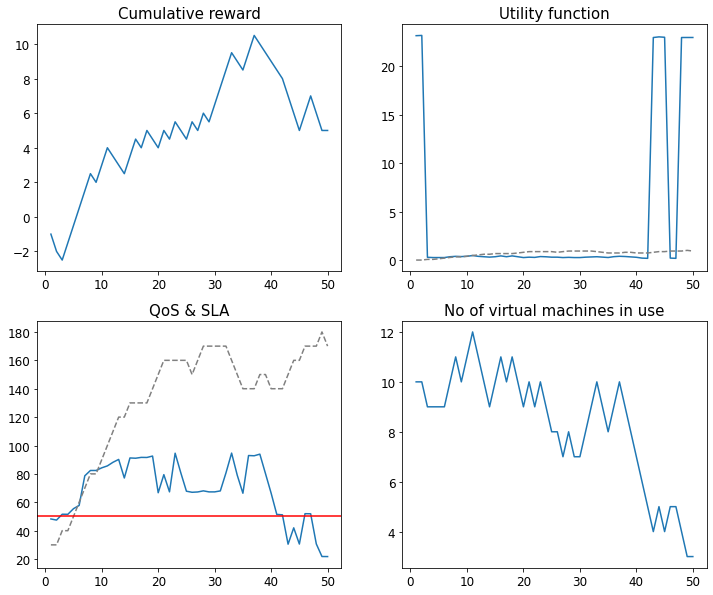

Cumulative reward at the end of the test:  5.0
Avg cost minus penalty per step:  3.94
Avg quality of service:  68.63
Avg no of virtual machines:  8.3


In [17]:
SCENARIO = 'Environment/Scenarios/test_scenario_2_PPO.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)

info {'Quality of Service': 47.82089783670016, 'Current cost': 475, 'Request': 20.0, 'Timer': 0.4182271957397461, 'VM type I': 9, 'VM type II': 2, 'VM type III': 3}


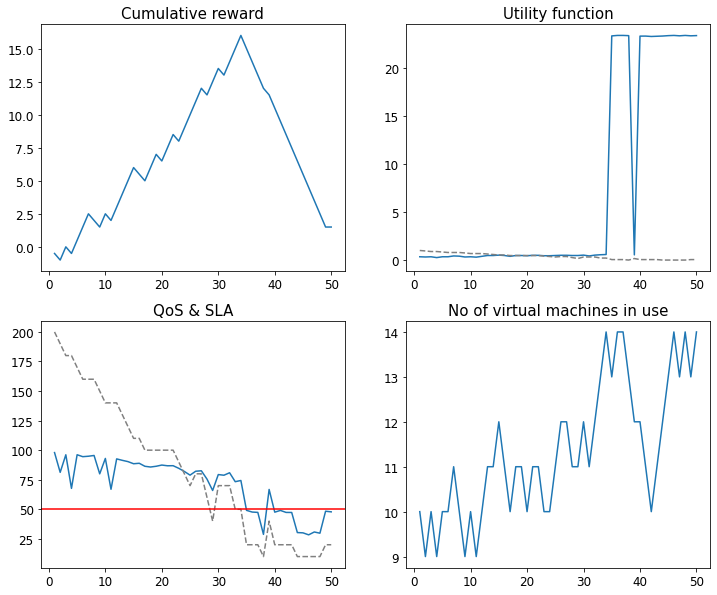

Cumulative reward at the end of the test:  1.5
Avg cost minus penalty per step:  7.33
Avg quality of service:  71.0
Avg no of virtual machines:  11.36


In [18]:
SCENARIO = 'Environment/Scenarios/test_scenario_3_PPO.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)

info {'Quality of Service': 50.31452093707302, 'Current cost': 620, 'Request': 20.0, 'Timer': 0.39749956130981445, 'VM type I': 11, 'VM type II': 5, 'VM type III': 3}


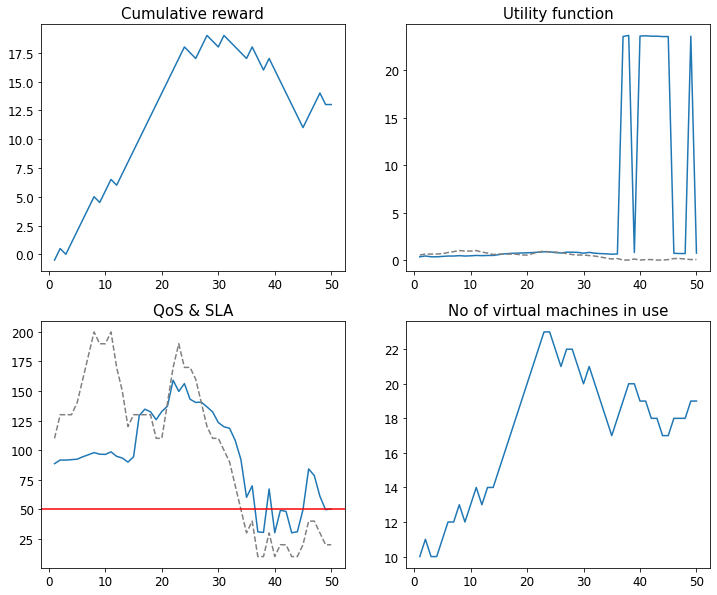

Cumulative reward at the end of the test:  13.0
Avg cost minus penalty per step:  4.76
Avg quality of service:  94.83
Avg no of virtual machines:  17.26


In [13]:
SCENARIO = 'Environment/Scenarios/test_scenario_4_PPO.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)

info {'Quality of Service': 51.91170597001777, 'Current cost': 165, 'Request': 170.0, 'Timer': 3.2747912406921387, 'VM type I': 3, 'VM type II': 3, 'VM type III': 0}


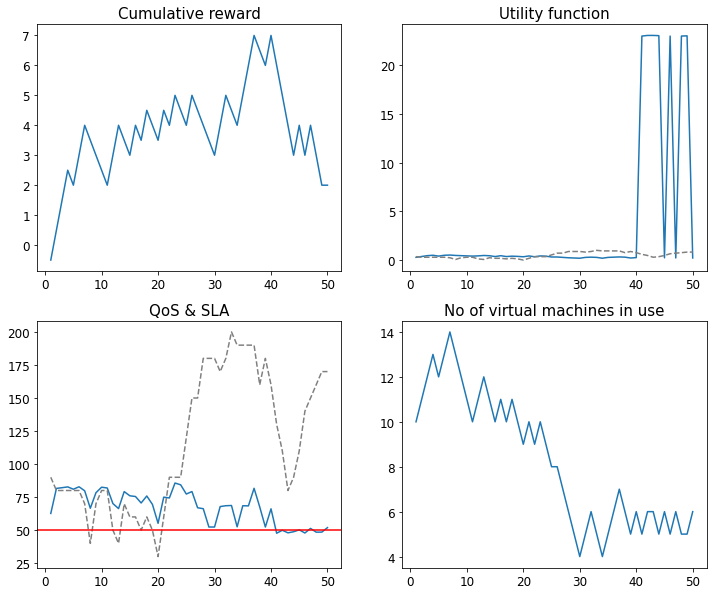

Cumulative reward at the end of the test:  2.0
Avg cost minus penalty per step:  3.52
Avg quality of service:  67.37
Avg no of virtual machines:  8.24


In [14]:
SCENARIO = 'Environment/Scenarios/test_scenario_5_PPO.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)